In [7]:
# Import libraries
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries and packages accordingly for neural networks
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision import models
from torchvision.datasets import ImageFolder


In [8]:
import tqdm # progress bar
import torch
import monai # PyTorch and Monai are good combo for Xray and MRI
import cv2 # openai
from PIL import Image # Handle different type of images
import ipywidgets as widgets

from monai.config import print_config
from monai.data import decollate_batch
from monai.metrics import ROCAUCMetric
from monai.networks.nets import DenseNet121
from monai.transforms import (
    Activations,
    EnsureChannelFirst,
    AsDiscrete,
    Compose,
    LoadImage,
    RandFlip,
    RandRotate, 
    RandZoom,
    ScaleIntensity
)

from monai.utils import set_determinism

In [44]:
import glob
import random
import shutil
from tqdm.auto import tqdm
import copy
import io
import PIL
from PIL import Image


In [35]:
print_config()

MONAI version: 1.5.2
Numpy version: 2.4.2
Pytorch version: 2.10.0+cpu
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: d:\ai_brain_tumor_dashboard\.venv\Lib\site-packages\monai\__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: NOT INSTALLED or UNKNOWN VERSION.
scikit-image version: NOT INSTALLED or UNKNOWN VERSION.
scipy version: 1.17.0
Pillow version: 12.1.0
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.25.0+cpu
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.2.2
pandas version: 3.0.0
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED

What to do:
- Dataset size 😄
- Class distribution (imbalance)
- Example images per class 😄
- Image dimensions / channels
- Corrupted or unreadable files
- Train/val/test/split strategy 😄
- Initial observations (noise, blur, artifacts, etc)

### Conclusions might be:
- Classes are imbalance (glioma dominates, etc)
- Image vary in resolution
- Some img have low contrast - helpful or not


In [34]:
# Set deterministic training for reproducibility
set_determinism(seed=42)

In [49]:
# Define data paths
BASE_DIR = 'D:/ai_brain_tumor_dashboard/data/'
TRAINING_FOLDER = os.path.join(BASE_DIR, 'Training')
TESTING_FOLDER = os.path.join(BASE_DIR, 'Testing')
VAL_FOLDER = os.path.join(BASE_DIR, 'Validation')
CLASSES = sorted(os.listdir(TRAINING_FOLDER))

In [50]:
# Create validation datset
image_files = glob.glob(os.path.join(TRAINING_FOLDER, '**/*.jpg'), recursive= True)
num_classes = 4
selected_images = random.sample(image_files, int(len(image_files)*0.2))

In [51]:
#Move the selected images to the validation directory
for image_path in tqdm(selected_images):
    #Get the class name from parent directory
    class_folder = os.path.basename(os.path.dirname(image_path))

    # Create a new folder in the validation directory for the current class
    val_class_path = os.path.join(VAL_FOLDER, class_folder)
    if not os.path.exists(val_class_path):
        os.makedirs(val_class_path)

    # Move the image to the corresponding validation class folder
    val_image_path = os.path.join(val_class_path, os.path.basename(image_path))
    shutil.move(image_path, val_image_path)

  0%|          | 0/914 [00:00<?, ?it/s]

In [52]:
folders = [TRAINING_FOLDER, VAL_FOLDER, TESTING_FOLDER]
train_size, val_size, test_size = [len(glob.glob(os.path.join(folder, '**/*.jpg'), recursive = True)) for folder in folders]


In [53]:
# Checking the number of images in Traning/Testing/Validation files
print(f'Train size: {train_size}\nValidation Size: {val_size}\nTest Size: {test_size}')

Train size: 3656
Validation Size: 2056
Test Size: 1311


In [54]:
class_name = sorted(x for x in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, x)))
num_classes = len(class_name)
total_image_files = [[os.path.join(BASE_DIR, class_name[i], x) for x in os.listdir(os.path.join(BASE_DIR, class_name[i]))]
                     for i in range(num_classes)]


In [ ]:
# num_each = [len(total_image_files[i]) for i in range(num_classes)]
# image_files_list = []
# image_class = []

# for i in range(num_classes):
#     image_files_list.extend(total_image_files[i])
#     image_class.extend([i] * num_each[i])
# num_total = len(image_class)
# image_width, image_height = PIL.Image.open(image_files_list[0]).size

# print(f"Total Image counts: {num_total}")
# print(f"Total dimensions: {image_width} * {image_height}")
# print(f"label_names: {class_name}")
# print(f"Label counts: {num_each}")

In [21]:
# Pipeline class for the EDA
class EDA:
    def __init__(self, training_folder, testing_folder, valid_folder, classes):
        self.training_folder = training_folder
        self.testing_folder = testing_folder
        self.valid_folder = valid_folder
        self.classes = classes

    def plot_samples(self):
        """
        Function to plot training samples
        """
        fig, ax = plt.subplots(1, 4, figsize=(10, 6))
        for idx, data in enumerate(self._get_training_samples().items()):
            cls, path = data
            img = cv2.imread(path)
            ax[idx].imshow(img)
            ax[idx].set_title(cls)
            ax[idx].axis('off')
        plt.show()

    def plot_counts(self, set_type):
        """
        Function to plot distribution counts.
        :param self: Description
        :param set_type (str): sets to plot counts for. Options: `train` & `set`
        """
        counts = self._get_counts(set_type=set_type)
        X = list(counts.keys())
        y = list(counts.values())

        # Plot counts
        plt.bar(X, y)
        plt.title(f'{set_type.capitalize()} Set Distribution')
        plt.xlabel('Class')
        plt.ylabel('Counts')
        plt.show()

    def _get_training_samples(self):
        """
        Function to retrieve a list of one sample per each class
        """
        paths = [os.path.join(self.training_folder, cls) for cls in self.classes]
        img_paths = {}
        for path, cls in zip(paths, self.classes):
            img_name = sorted(os.listdir(path))[0]
            img_paths[cls] = os.path.join(path, img_name)
        return img_paths
            
    def _get_counts(self, set_type):
        """
        Function to get the count of each class in a given set
                
        :param `set_type`: get counts for either `train` and `test`
        return dictionary of counts
        """
        if set_type=='train':
            folder = self.training_folder
        elif set_type == 'test':
            folder = self.testing_folder
        else:
            folder = self.valid_folder

        counts = {}

        #Iterate through class
        for class_type in self.classes:
            dir = os.path.join(folder, class_type)
            counts[class_type] = len(os.listdir(dir))
            
        return counts

## Data Distribution

In [22]:
# initialize explorer
eda = EDA(TRAINING_FOLDER, TESTING_FOLDER, VAL_FOLDER, CLASSES)

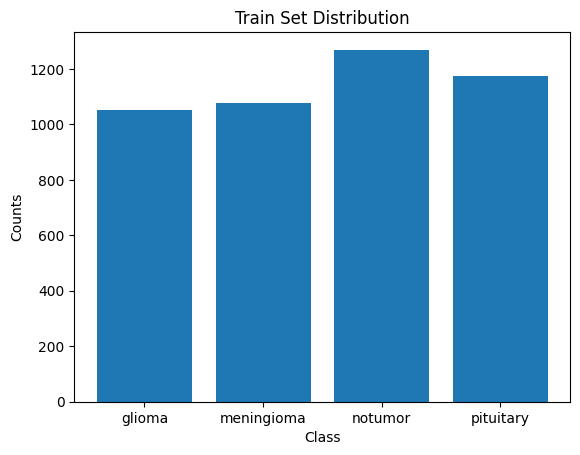

In [23]:
# Plot train counts
eda.plot_counts('train')

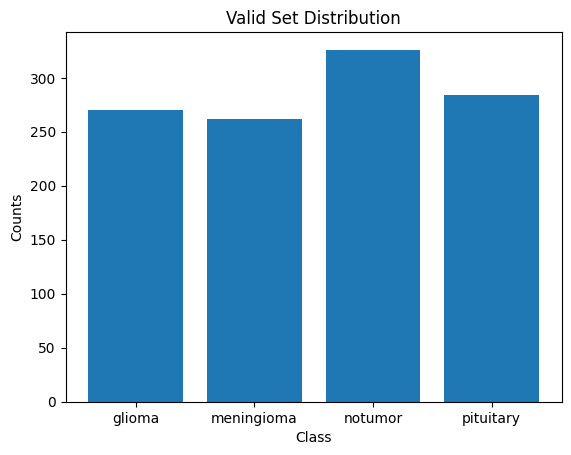

In [24]:
# Plot validation counts
eda.plot_counts('valid')

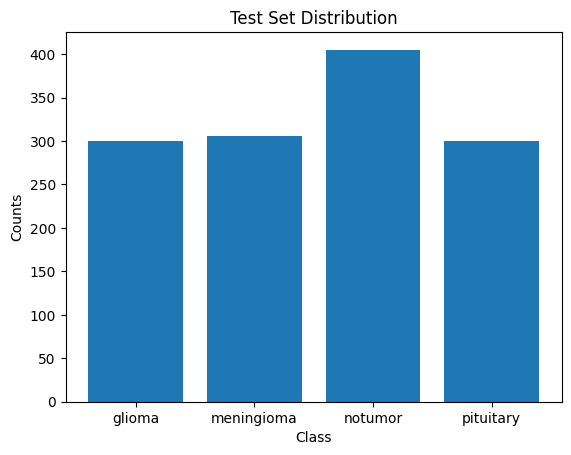

In [25]:
# Plot test count
eda.plot_counts('test')

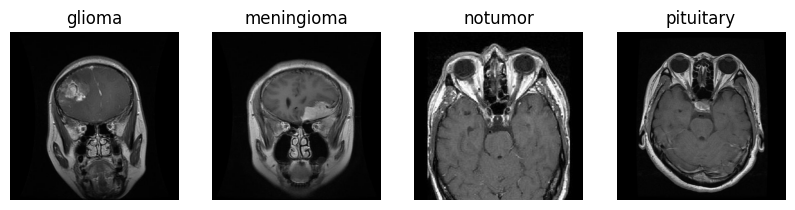

In [26]:
# Plot samples
eda.plot_samples()

## Preprocess data

In [27]:
class Config:
    batch_size = 32
    epochs = 50
    lr = 1e-4
    n_classes = len(CLASSES)
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

### Define MONAI transform, Dataset and Dataloader to pre-process the data

Why MONAI DenseNet121?


In [ ]:
# Define network and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenseNet121(spatial_dims=2, in_channels=1, out_channels=num_classes).to(device)
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), 1e-5)
max_epochs = 4
val_interval = 1
auc_metric = ROCAUCMetric()

In [ ]:
## Define MONAI tranform
train_transform = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    ScaleIntensity(),
    RandRotate(range_x=np.pi / 12, prob = 0.5, keep_size=True),
    RandFlip(spatial_axis=0, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5)
])  

# Transform validation dataset
val_tranform = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    ScaleIntensity() # No use Rotation or Flip, we want to see how good our image is performing under "real" condition after learning through tons of flipping and rotating images
])

y_pred_trans = Compose([
    Activations(softmax=True)
])
y_trans = Compose([
    AsDiscrete(to_onehot=num_classes)
])
      

In [4]:
import torch
import torchvision.models as models

In [9]:
### VGG16
# Loading VGG16 with pre-trained weights
vgg16 = models.vgg16(weights='IMAGENET1K_V1')

# Build the CNN using `torch.nn.Module` class and the VGG16 pretrained architecture
class Net(nn.Module):
    def __init__(self, num_classes):
        super(Net, self).__init__()

        # Load in VGG16
        num_input_features = vgg16.classifier[6].in_features

        # Freeze layers
        for param in vgg16.parameters():
            param.requires_grad = False
        
        # Define feed forward network
        vgg16.classifier[6] = nn.Linear(num_input_features, num_classes)
        for param in vgg16.classifier.parameters():
            param.requires_grad = False

        self.model = vgg16

    def forward(self, x):
        return self.model(x)

    

### Create Early Stopping Callback
Create an early stopping callback that will stop the training and restore the best weights when a certain patience interval is hit

In [10]:
class EarlyStopping():
    def __init__(self, patience=5, min_delta=0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_model = None
        self.best_loss = None
        self.counter = 0
        self.status = ''

    def __call__(self, model, val_loss):
        if self.best_loss == None:
            self.best_loss = val_loss
            self.best_model = copy.deepcopy(model)
        elif self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_model.load_state_dict(model.state_dict())
        elif self.best_loss - val_loss < self.min_delta:
            self.counter +=1
            if self.counter >= self.patience:
                self.status = f"Stopped on {self.counter}"
                if self.restore_best_weights:
                    model.load_state_dict(self.best_model.state_dict())
                return True
        self.status = f'{self.counter}/{self.patience}'
        return False